<a href="https://colab.research.google.com/github/quinterogilalejandro-wq/MACHINE-LEARNING-/blob/main/Semana_10_Librer%C3%ADas_Numpy%2CPandas%2C_Sickit_Learn_Implementaci%C3%B3n_PARTE_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Demostración de head(), info() y describe():

--- HEAD ---
   id         nombre  edad  ingreso  gasto_mensual        ciudad
0   1  Roberto Silva    59     5279           4124      Medellin
1   2    Sofia Gomez    71     4548           2877  Barranquilla
2   3  Roberto Velez    56     7499           5463  Barranquilla
3   4    Carlos Diaz    58     5031           3833     Cartagena
4   5    Sofia Gomez    66     2441           1927  Barranquilla

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   id             1000 non-null   int64 
 1   nombre         1000 non-null   object
 2   edad           1000 non-null   int64 
 3   ingreso        1000 non-null   int64 
 4   gasto_mensual  1000 non-null   int64 
 5   ciudad         1000 non-null   object
dtypes: int64(4), object(2)
memory usage: 47.0+ KB

--- DESCRIBE ---
                

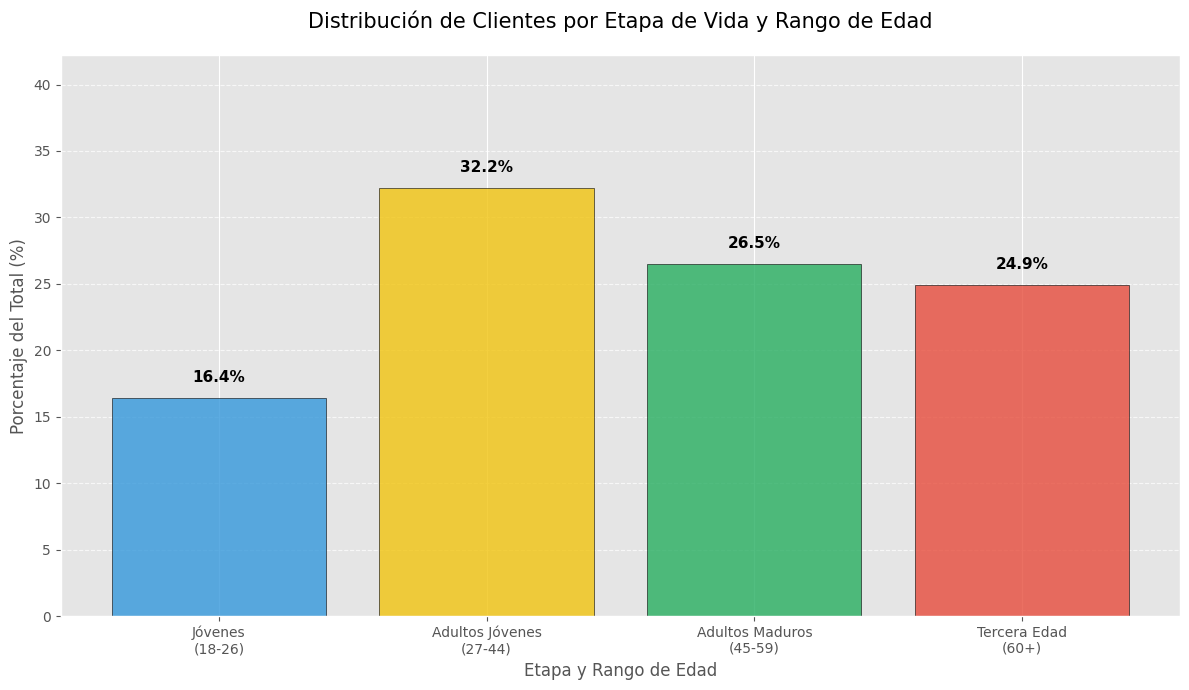


--- Distribución de Ingresos 
Porcentaje de clientes con ingreso > 3.000: 75.40%
Porcentaje de clientes con ingreso <= 3.000: 24.60%


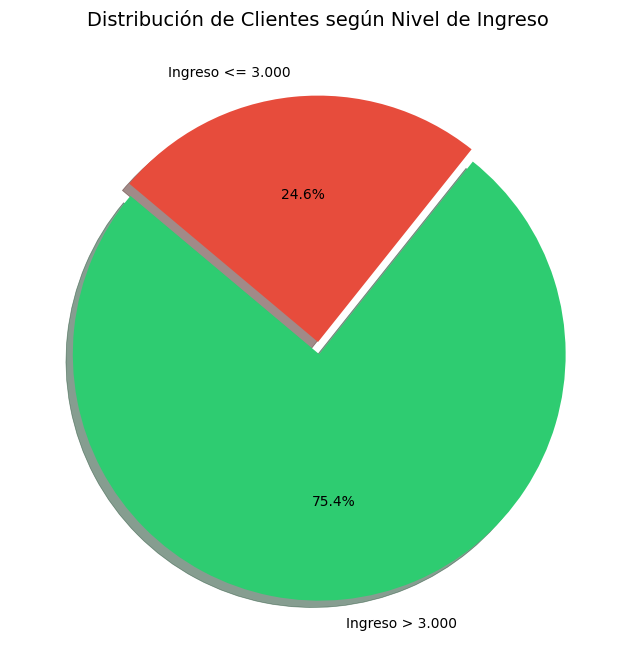


3. Conteo de personas con ingreso > 3000 por ciudad:
ciudad
Barranquilla    118
Pereira         117
Cartagena       116
Cali            114
Medellin        103
Bucaramanga     102
Bogota           84
dtype: int64


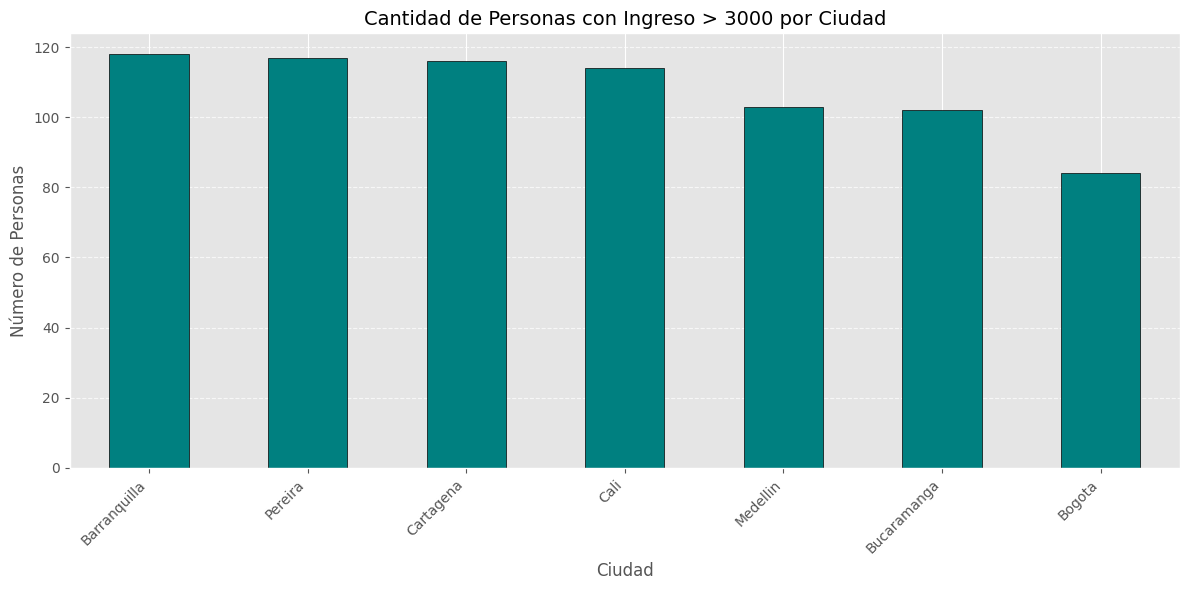


5. Ordenamiento por ingreso (Descendente):
      id        nombre  edad  ingreso  gasto_mensual        ciudad                etapa_vida
238  239      Ana Sosa    26     7996           5291   Bucaramanga          Jóvenes\n(18-26)
473  474  Carlos Marin    64     7989           5345          Cali       Tercera Edad\n(60+)
483  484   Elena Lopez    40     7981           5055  Barranquilla  Adultos Jóvenes\n(27-44)
795  796    Luis Lopez    29     7975           6358      Medellin  Adultos Jóvenes\n(27-44)
945  946   Maria Marin    29     7966           5245        Bogota  Adultos Jóvenes\n(27-44)

6. Archivo 'usuarios_ordenados.csv' generado exitosamente.

7. Clientes mayores de 30 años (Orden: Edad, Ingreso, Gasto):
             nombre  edad  ingreso  gasto_mensual        ciudad
126    Elena Castro    74     6973           5423       Pereira
830      Lucia Ruiz    74     6555           4666          Cali
718      Sofia Sosa    74     6372           4400       Pereira
565       Ana Silva

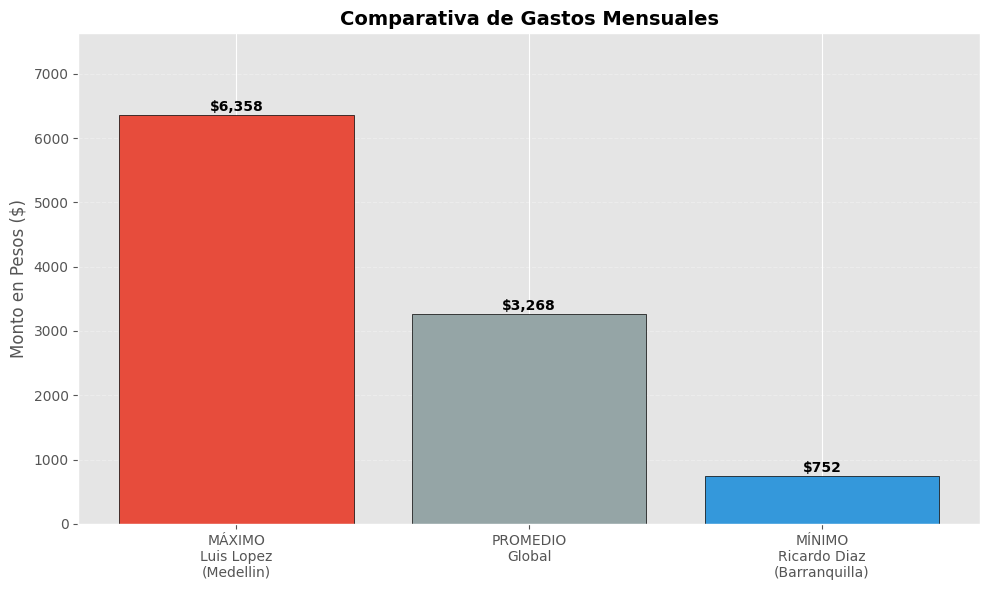

CLIENTE MAYOR GASTO: Luis Lopez de Medellin ($6,358.00)
GASTO PROMEDIO: $3,267.51
CLIENTE MENOR GASTO: Ricardo Diaz de Barranquilla ($752.00)

9. El gasto promedio general es: 3267.51
10. El ingreso promedio general es: 4643.88


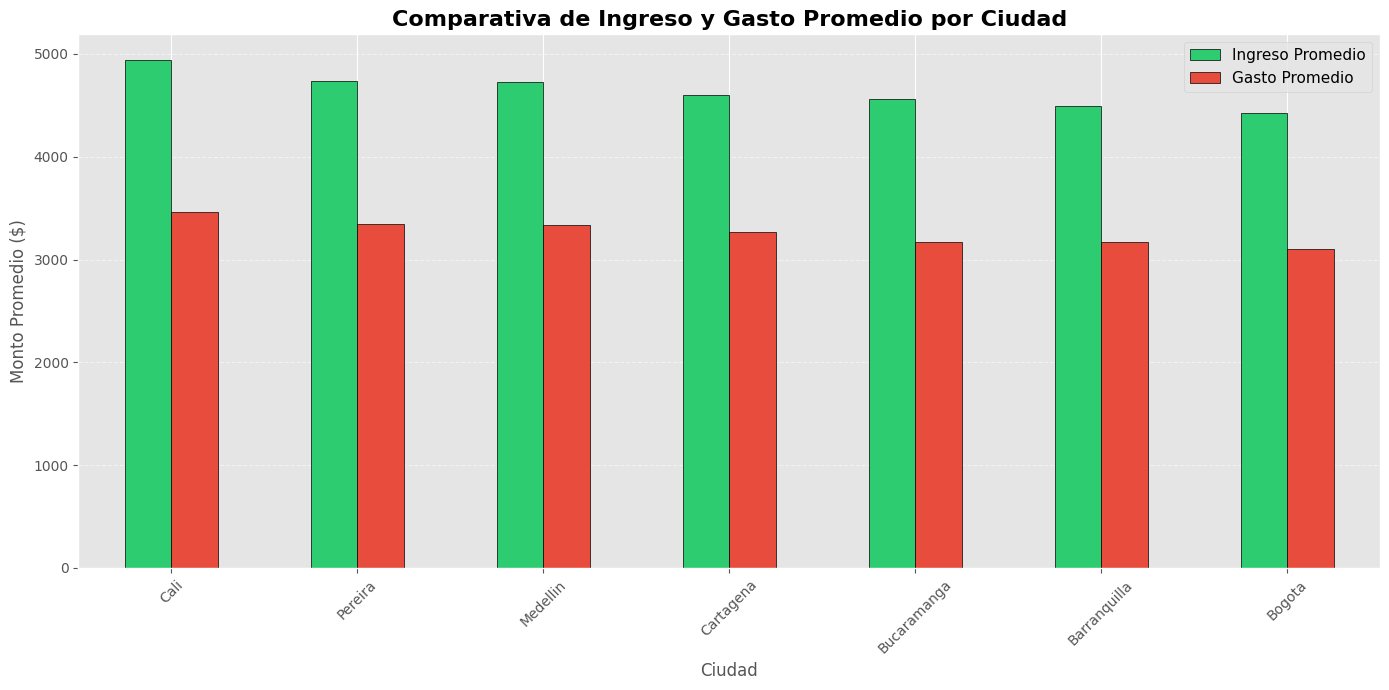


--- Tabla de Promedios por Ciudad (Ordenado por Ingreso) ---
                ingreso gasto_mensual
ciudad                               
Cali          $4,943.74     $3,464.24
Pereira       $4,739.17     $3,342.77
Medellin      $4,727.05     $3,338.88
Cartagena     $4,603.05     $3,267.93
Bucaramanga   $4,566.32     $3,172.85
Barranquilla  $4,489.11     $3,169.43
Bogota        $4,429.09     $3,105.89

=== Análisis finalizado con éxito ===


/tmp/ipykernel_16119/1418395064.py:176: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  print(resumen_ciudad.applymap('${:,.2f}'.format))


In [44]:
import pandas as pd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import KBinsDiscretizer

# Carga de datos
df = pd.read_csv("usuarios_1000.csv")


# 1. Demostración de funciones iniciales
print("1. Demostración de head(), info() y describe():")
print("\n--- HEAD ---")
print(df.head())
print("\n--- INFO ---")
df.info()
print("\n--- DESCRIBE ---")
print(df.describe())



# 2. Seleccione la columna “edad” y presente el resultado.
df = pd.read_csv("usuarios_1000.csv")
limites = [17, 26, 44, 59, 120]
etapas_con_rango = [
    'Jóvenes\n(18-26)',
    'Adultos Jóvenes\n(27-44)',
    'Adultos Maduros\n(45-59)',
    'Tercera Edad\n(60+)'
]
df['etapa_vida'] = pd.cut(df['edad'], bins=limites, labels=etapas_con_rango)
porcentajes = df['etapa_vida'].value_counts(normalize=True).sort_index() * 100
print("--- Distribución Porcentual ---")
print(porcentajes.map('{:.2f}%'.format))
#GRÁFICA
plt.figure(figsize=(12, 7))
colores = ['#3498db', '#f1c40f', '#27ae60', '#e74c3c']
barras = plt.bar(porcentajes.index, porcentajes.values, color=colores, edgecolor='black', alpha=0.8)
plt.title("Distribución de Clientes por Etapa de Vida y Rango de Edad", fontsize=15, pad=20)
plt.xlabel("Etapa y Rango de Edad", fontsize=12)
plt.ylabel("Porcentaje del Total (%)", fontsize=12)
plt.ylim(0, porcentajes.max() + 10)
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 1, f'{yval:.1f}%',
             ha='center', va='bottom', fontweight='bold', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#3.Mostrar solo aquellos registros en donde la columna “ingreso” sea mayor a 3000
print("\n--- Distribución de Ingresos ")
es_mayor_3000 = df["ingreso"] > 3000
distribucion_ingresos = es_mayor_3000.value_counts(normalize=True) * 100
distribucion_ingresos.index = ['Ingreso > 3.000', 'Ingreso <= 3.000']
print(f"Porcentaje de clientes con ingreso > 3.000: {distribucion_ingresos['Ingreso > 3.000']:.2f}%")
print(f"Porcentaje de clientes con ingreso <= 3.000: {distribucion_ingresos['Ingreso <= 3.000']:.2f}%")
#GRAFICA
plt.figure(figsize=(8, 8))
colores_ingreso = ['#2ecc71', '#e74c3c']

plt.pie(
    distribucion_ingresos,
    labels=distribucion_ingresos.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colores_ingreso,
    explode=(0.05, 0),
    shadow=True
)

plt.title("Distribución de Clientes según Nivel de Ingreso", fontsize=14)
plt.show()

# 4. Cantidad de personas con ingreso > 3000 por ciudad
print("\n3. Conteo de personas con ingreso > 3000 por ciudad:")
ingreso_alto = df[df["ingreso"] > 3000]
conteo_ordenado = ingreso_alto.groupby("ciudad").size().sort_values(ascending=False)
print(conteo_ordenado)
#GRAFICA
ingreso_alto = df[df["ingreso"] > 3000]
conteo_ordenado = ingreso_alto.groupby("ciudad").size().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
conteo_ordenado.plot(kind='bar', color='teal', edgecolor='black')
plt.title("Cantidad de Personas con Ingreso > 3000 por Ciudad", fontsize=14)
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Número de Personas", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# 5. Ordenamiento por ingreso (Descendente)
print("\n5. Ordenamiento por ingreso (Descendente):")
ordenado = df.sort_values(by="ingreso", ascending=False)
print(ordenado.head())

# 6. Almacenar resultados en nuevo archivo
ordenado.to_csv("usuarios_ordenados.csv", index=False)
print("\n6. Archivo 'usuarios_ordenados.csv' generado exitosamente.")

# 7. Filtrar mayores de 30 años y ordenar por múltiples criterios
print("\n7. Clientes mayores de 30 años (Orden: Edad, Ingreso, Gasto):")
mayores_30 = df[df["edad"] >= 31].copy()
resultado_7 = mayores_30.sort_values(
    by=["edad", "ingreso", "gasto_mensual"],
    ascending=[False, False, False]
)
print(resultado_7[["nombre", "edad", "ingreso", "gasto_mensual", "ciudad"]])


# 8. Cliente con mayor gasto
gasto_max = df["gasto_mensual"].max()
gasto_min = df["gasto_mensual"].min()
gasto_prom = df["gasto_mensual"].mean()
cliente_max = df[df["gasto_mensual"] == gasto_max].iloc[0]
cliente_min = df[df["gasto_mensual"] == gasto_min].iloc[0]
etiquetas = [
    f"MÁXIMO\n{cliente_max['nombre']}\n({cliente_max['ciudad']})",
    "PROMEDIO\nGlobal",
    f"MÍNIMO\n{cliente_min['nombre']}\n({cliente_min['ciudad']})"
]
valores = [gasto_max, gasto_prom, gasto_min]
colores = ['#e74c3c', '#95a5a6', '#3498db']

# GRAFICO
plt.figure(figsize=(10, 6))
barras = plt.bar(etiquetas, valores, color=colores, edgecolor='black')
for barra in barras:
    yval = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, yval + 10, f'${yval:,.0f}',
             ha='center', va='bottom', fontweight='bold')
plt.title("Comparativa de Gastos Mensuales", fontsize=14, fontweight='bold')
plt.ylabel("Monto en Pesos ($)")
plt.ylim(0, gasto_max * 1.2) # Espacio para el texto arriba
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()
print(f"CLIENTE MAYOR GASTO: {cliente_max['nombre']} de {cliente_max['ciudad']} (${gasto_max:,.2f})")
print(f"GASTO PROMEDIO: ${gasto_prom:,.2f}")
print(f"CLIENTE MENOR GASTO: {cliente_min['nombre']} de {cliente_min['ciudad']} (${gasto_min:,.2f})")








# 9. Calcular gasto promedio
promedio_gasto = df["gasto_mensual"].mean()
print(f"\n9. El gasto promedio general es: {promedio_gasto:.2f}")

# 10. Calcular ingreso promedio
promedio_ingreso = df["ingreso"].mean()
print(f"10. El ingreso promedio general es: {promedio_ingreso:.2f}")
resumen_ciudad = df.groupby('ciudad')[['ingreso', 'gasto_mensual']].mean().sort_values(by='ingreso', ascending=False)

# GRAFICO
ax = resumen_ciudad.plot(
    kind='bar',
    figsize=(14, 7),
    color=['#2ecc71', '#e74c3c'],
    edgecolor='black',
    rot=45
)

plt.title("Comparativa de Ingreso y Gasto Promedio por Ciudad", fontsize=16, fontweight='bold')
plt.xlabel("Ciudad", fontsize=12)
plt.ylabel("Monto Promedio ($)", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(["Ingreso Promedio", "Gasto Promedio"], fontsize=11)
plt.tight_layout()
plt.show()
print("\n--- Tabla de Promedios por Ciudad (Ordenado por Ingreso) ---")
print(resumen_ciudad.applymap('${:,.2f}'.format))

print("\n=== Análisis finalizado con éxito ===")